# Base pseudo-code

In [35]:
import torch
from torch import nn, optim

def forsaken(f_theta_0, T, lambda_, omega, P, D_f, eta_mu, xi):
    model_t = f_theta_0
    theta_0 = [param.clone().detach() for param in f_theta_0.parameters()]
    mu = [torch.zeros_like(param, requires_grad=True) for param in theta_0]
    criterion = nn.KLDivLoss()
    optimizer = optim.LBFGS(mu, lr=eta_mu)

    for _ in range(T):
        with torch.no_grad():
            for param, theta, m in zip(model_t.parameters(), theta_0, mu):
                param.copy_((theta - xi * m).detach())

        upsilon = model_t(D_f)
        loss = criterion(upsilon, P) + lambda_ * omega * sum(torch.norm(m, p=1) for m in mu)

        loss.backward()
        optimizer.step()

    return model_t



# Code

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import Subset, DataLoader
import torch.nn.functional as F
from torch.nn.utils.stateless import functional_call
import copy
import random
import matplotlib.pyplot as plt


In [25]:
# ---- Transform ----
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# ---- Load datasets ----
train_dataset_full = datasets.MNIST(root="./data", train=True, transform=transform, download=True)
test_dataset_full = datasets.MNIST(root="./data", train=False, transform=transform, download=True)

# ---- Forget Set ----
def create_forget_set(dataset, num_forget=100):
    forget_indices = random.sample(range(len(dataset)), num_forget)  # Randomly sample forget data
    D_f = Subset(dataset, forget_indices)  # Forget Set
    D_rest_indices = list(set(range(len(dataset))) - set(forget_indices))  # Rest of the data
    D_rest = Subset(dataset, D_rest_indices)  # Remaining training data

    # DataLoaders for each set
    forget_loader = DataLoader(D_f, batch_size=num_forget, shuffle=False)  # DataLoader for forget set
    train_loader = DataLoader(D_rest, batch_size=64, shuffle=True)  # DataLoader for remaining training data
    full_loader = DataLoader(dataset, batch_size=64, shuffle=True)  # DataLoader for the full training dataset

    return forget_loader, train_loader, full_loader

# ---- Sample Set from Test Data ----
def create_sample_set(dataset, num_sample=200):
    sample_indices = random.sample(range(len(dataset)), num_sample)
    D_sample = Subset(dataset, sample_indices)
    D_test_rest_indices = list(set(range(len(dataset))) - set(sample_indices))
    D_test_rest = Subset(dataset, D_test_rest_indices)
    sample_loader = DataLoader(D_sample, batch_size=64, shuffle=False)
    test_loader = DataLoader(D_test_rest, batch_size=64, shuffle=False)
    return test_loader, sample_loader, sample_indices

# ---- Omega Set from Training Data (proportion from full dataset) ----
def create_omega_set(dataset, proportion=0.1):
    num_omega = int(len(dataset) * proportion)
    omega_indices = random.sample(range(len(dataset)), num_omega)
    omega_set = Subset(dataset, omega_indices)
    return omega_set, omega_indices

In [4]:
class FullyConnectedNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(784, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [5]:
def train_model(model, train_loader, lr, epochs):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.01)
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for images, labels in train_loader:
            optimizer.zero_grad()
            output = model(images)
            loss = criterion(output, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(train_loader):.4f}")

In [6]:
def verification_error(theta_0, theta_t):
    return torch.sqrt(sum(torch.norm(theta_0[name] - theta_t[name], p=2) ** 2 for name in theta_0))

In [39]:
def forsaken(f_theta_0, T, lambda_, omega, P, D_f, eta_mu, xi, optimizer, retrained_model = None):
    model_t = copy.deepcopy(f_theta_0)
    theta_0 = {name: param.clone().detach() for name, param in model_t.named_parameters()}
    log_verification_error = retrained_model != None
    if (log_verification_error):
        theta_retrained = {name: param.clone().detach() for name, param in retrained_model.named_parameters()}
    mu = {name: torch.zeros_like(param, requires_grad=True) for name, param in theta_0.items()}
    criterion = nn.KLDivLoss(reduction='batchmean')

    if optimizer == 'SGD':
        optimizer = optim.SGD(list(mu.values()), lr=eta_mu)
    elif optimizer == 'LBFGS':
        optimizer = optim.LBFGS(list(mu.values()), lr=eta_mu)

    loss_history = []
    verification_error_history = []

    last_loss = None  # Track the last computed loss
    last_verification_error = None # Track the last computed params
    def closure():
        nonlocal last_loss, last_verification_error, log_verification_error, theta_retrained
        optimizer.zero_grad()
        new_params = {name: theta_0[name] - xi * mu[name] for name in theta_0}
        upsilon = functional_call(model_t, new_params, D_f)
        log_probs = F.log_softmax(upsilon, dim=1)
        loss = criterion(log_probs, P) + lambda_ * omega * sum(torch.norm(m, p=1) for m in mu.values())
        loss.backward()
        last_loss = loss.item()
        if (log_verification_error):
            last_verification_error = verification_error(theta_retrained, new_params).item()
        return loss

    for _ in range(T):
        optimizer.step(closure)
        loss_history.append(last_loss)
        if (log_verification_error):
            verification_error_history.append(last_verification_error)
            print(f"Iteration {_+1}, Loss: {last_loss:.4f}, Verification Error: {last_verification_error:.4f}")
        else:
            print(f"Iteration {_+1}, Loss: {last_loss:.4f}")

    # After optimization, update the model parameters
    final_params = {name: theta_0[name] - xi * mu[name].detach() for name in theta_0}
    for name, param in model_t.named_parameters():
            param.data.copy_(final_params[name])
    
    print("Fin de la procédure Forsaken.")
    
    plt.plot(loss_history)
    plt.xlabel('Iteration')
    plt.ylabel('Forgetting loss')
    plt.title('Forgetting loss during Forsaken Optimization')
    plt.show()

    if (log_verification_error):
        plt.plot(verification_error_history)
        plt.xlabel('Iteration')
        plt.ylabel('Verification error')
        plt.title('Verification error during Forsaken Optimization')
        plt.show()

    return model_t


In [9]:
def evaluate_model(model, data_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in data_loader:
            outputs = model(images)
            _, preds = torch.max(outputs, dim=1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()
    return 100 * correct / total

# Execution

In [32]:
# ---- Create all datasets and loaders ----
forget_loader, train_loader, full_loader = create_forget_set(train_dataset_full, num_forget=100)
test_loader, sample_loader, sample_indices = create_sample_set(test_dataset_full, num_sample=200)
omega_set, omega_indices = create_omega_set(train_dataset_full, proportion=0.01)

# ---- Optional: print summary ----
print(f"Training set (excluding forget): {len(train_loader.dataset)}")
print(f"Forget set: {len(forget_loader.dataset)}")
print(f"Omega set: {len(omega_indices)}")
print(f"Test set (excluding sample): {len(test_loader.dataset)}")
print(f"Sample set: {len(sample_loader.dataset)}")

Training set (excluding forget): 59900
Forget set: 100
Omega set: 600
Test set (excluding sample): 9800
Sample set: 200


In [33]:
model_target = FullyConnectedNN()
train_model(model_target, full_loader, 0.01, 5)

Epoch 1/5, Loss: 0.7849
Epoch 2/5, Loss: 0.3038
Epoch 3/5, Loss: 0.2466
Epoch 4/5, Loss: 0.2084
Epoch 5/5, Loss: 0.1793


In [34]:
model_retrained = FullyConnectedNN()
train_model(model_retrained, train_loader, 0.01, 5)

Epoch 1/5, Loss: 0.7843
Epoch 2/5, Loss: 0.3105
Epoch 3/5, Loss: 0.2524
Epoch 4/5, Loss: 0.2147
Epoch 5/5, Loss: 0.1857


Iteration 1, Loss: 3.5612, Verification Error: 17.9728
Iteration 2, Loss: 3.1726, Verification Error: 17.9312
Iteration 3, Loss: 3.0329, Verification Error: 17.9400
Iteration 4, Loss: 2.9085, Verification Error: 17.9208
Iteration 5, Loss: 2.8132, Verification Error: 17.9210
Iteration 6, Loss: 2.7164, Verification Error: 17.9185
Iteration 7, Loss: 2.6476, Verification Error: 17.9107
Iteration 8, Loss: 2.6006, Verification Error: 17.9180
Iteration 9, Loss: 2.5549, Verification Error: 17.9101
Iteration 10, Loss: 2.5192, Verification Error: 17.9060
Iteration 11, Loss: 2.4853, Verification Error: 17.9102
Iteration 12, Loss: 2.4594, Verification Error: 17.9053
Iteration 13, Loss: 2.4313, Verification Error: 17.9066
Iteration 14, Loss: 2.4017, Verification Error: 17.9068
Iteration 15, Loss: 2.3792, Verification Error: 17.9010
Iteration 16, Loss: 2.3558, Verification Error: 17.9029
Iteration 17, Loss: 2.3337, Verification Error: 17.9027
Iteration 18, Loss: 2.3098, Verification Error: 17.8991
I

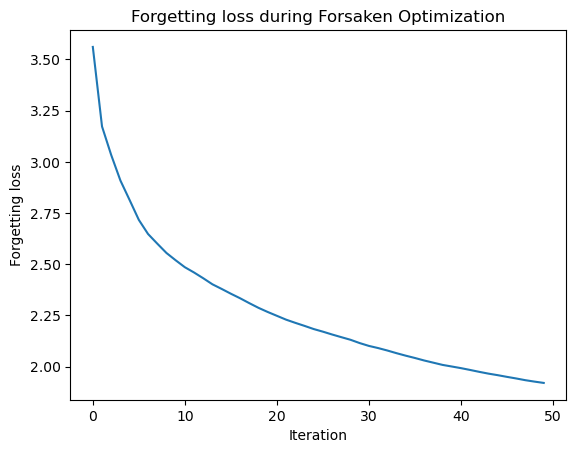

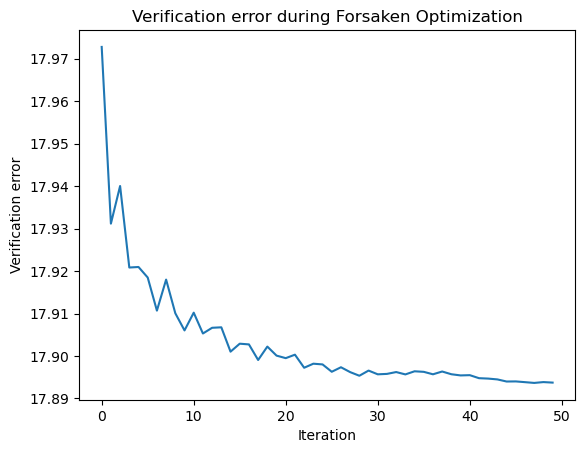

In [40]:
P = torch.full((len(forget_loader), 10), 1/10)

T = 50
lambda_ = 0.0001
omega = 1.0
eta_mu = 0.1
xi = 0.01

D_f, _ = next(iter(forget_loader))

model_forsaken = forsaken(
    f_theta_0=model_target,
    T=T,
    lambda_=lambda_,
    omega=omega,
    P=P,
    D_f=D_f,
    eta_mu=eta_mu,
    xi=xi,
    optimizer = 'LBFGS',
    retrained_model = model_retrained
)


In [41]:

accuracy_forget = evaluate_model(model_forsaken, forget_loader)
print(f"Accuracy sur D_f après Forsaken : {accuracy_forget:.2f}%")

accuracy_base = evaluate_model(model_target, forget_loader)
print(f"Accuracy sur D_f sans Forsaken : {accuracy_base:.2f}%")

accuracy_retrained = evaluate_model(model_retrained, forget_loader)
print(f"Accuracy sur D_f avec réentraînement: {accuracy_retrained:.2f}%")

accuracy_forget_test = evaluate_model(model_forsaken, test_loader)
print(f"Accuracy sur base de test après Forsaken : {accuracy_forget_test:.2f}%")

accuracy_base_test = evaluate_model(model_target, test_loader)
print(f"Accuracy sur base de test sans Forsaken : {accuracy_base_test:.2f}%")

accuracy_retrained_test = evaluate_model(model_retrained, test_loader)
print(f"Accuracy sur base de test sans Forsaken : {accuracy_retrained_test:.2f}")


Accuracy sur D_f après Forsaken : 87.00%
Accuracy sur D_f sans Forsaken : 98.00%
Accuracy sur D_f avec réentraînement: 97.00%
Accuracy sur base de test après Forsaken : 88.65%
Accuracy sur base de test sans Forsaken : 95.11%
Accuracy sur base de test sans Forsaken : 94.91


### Gaussian Poisoning

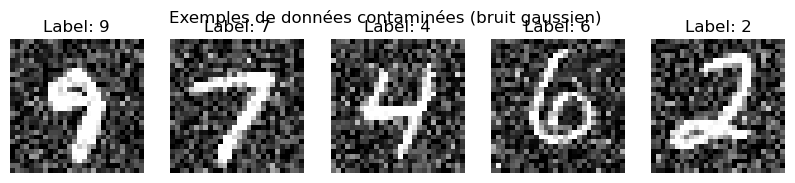

In [38]:
import torch
import random
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import TensorDataset, DataLoader

# Configuration
contamination_ratio = 0.6
subset_size = 10000  # Limiter à 10 000 images pour éviter surcharge mémoire

# Load MNIST (transform pas appliqué ici)
raw_dataset = datasets.MNIST(root="./data", train=True, download=True)
raw_images = raw_dataset.data[:subset_size].float() / 255.0
raw_labels = raw_dataset.targets[:subset_size]

# Déterminer les indices contaminés
num_total = len(raw_images)
num_contaminated = int(num_total * contamination_ratio)
contaminated_indices = random.sample(range(num_total), num_contaminated)
clean_indices = list(set(range(num_total)) - set(contaminated_indices))

# Fonction d'ajout de bruit
def add_gaussian_noise(images, mean=0.2, std=0.2):
    noise = torch.randn_like(images) * std + mean
    return torch.clamp(images + noise, 0.0, 1.0)

# Appliquer le bruit uniquement sur les images contaminées
contaminated_images = add_gaussian_noise(raw_images[contaminated_indices])
clean_images = raw_images[clean_indices]

# Normalisation manuelle
contaminated_images = (contaminated_images - 0.1307) / 0.3081
clean_images = (clean_images - 0.1307) / 0.3081

# Ajouter la dimension canal
contaminated_images = contaminated_images.unsqueeze(1)
clean_images = clean_images.unsqueeze(1)

# Fusion des datasets
train_images = torch.cat([clean_images, contaminated_images], dim=0)
train_labels = torch.cat([raw_labels[clean_indices], raw_labels[contaminated_indices]], dim=0)

# Création des dataloaders
noisy_train_dataset = TensorDataset(train_images, train_labels)
noisy_train_loader = DataLoader(noisy_train_dataset, batch_size=64, shuffle=True)

# Forget set = uniquement les contaminés
forget_dataset = TensorDataset(contaminated_images, raw_labels[contaminated_indices])
forget_loader = DataLoader(forget_dataset, batch_size=64, shuffle=False)

# Affichage de quelques exemples
fig, axes = plt.subplots(1, 5, figsize=(10, 2))
for i in range(5):
    axes[i].imshow(contaminated_images[i].squeeze(), cmap='gray')
    axes[i].set_title(f"Label: {raw_labels[contaminated_indices[i]].item()}")
    axes[i].axis('off')
plt.suptitle("Exemples de données contaminées (bruit gaussien)")
plt.show()


In [106]:
model_noise = FullyConnectedNN()
train_model(model_noise, train_loader=noisy_train_loader, lr=0.01, epochs=25)


Epoch 1/25, Loss: 2.0213
Epoch 2/25, Loss: 1.0823
Epoch 3/25, Loss: 0.6290
Epoch 4/25, Loss: 0.4847
Epoch 5/25, Loss: 0.4173
Epoch 6/25, Loss: 0.3728
Epoch 7/25, Loss: 0.3447
Epoch 8/25, Loss: 0.3228
Epoch 9/25, Loss: 0.3045
Epoch 10/25, Loss: 0.2887
Epoch 11/25, Loss: 0.2745
Epoch 12/25, Loss: 0.2603
Epoch 13/25, Loss: 0.2495
Epoch 14/25, Loss: 0.2379
Epoch 15/25, Loss: 0.2274
Epoch 16/25, Loss: 0.2164
Epoch 17/25, Loss: 0.2066
Epoch 18/25, Loss: 0.1967
Epoch 19/25, Loss: 0.1889
Epoch 20/25, Loss: 0.1805
Epoch 21/25, Loss: 0.1722
Epoch 22/25, Loss: 0.1634
Epoch 23/25, Loss: 0.1559
Epoch 24/25, Loss: 0.1486
Epoch 25/25, Loss: 0.1426


In [107]:
forget_dataset = TensorDataset(contaminated_images, raw_labels[contaminated_indices])
forget_loader = DataLoader(forget_dataset, batch_size=64, shuffle=False)

# On prend un batch du forget set pour le test
images_forget, labels_forget = next(iter(forget_loader))

# P = distribution uniforme cible
P = torch.full((images_forget.size(0), 10), 1/10)


C:\Users\mathi\AppData\Local\Temp\ipykernel_10952\560380032.py:17: FutureWarning: `torch.nn.utils.stateless.functional_call` is deprecated as of PyTorch 2.0 and will be removed in a future version of PyTorch. Please use `torch.func.functional_call` instead which is a drop-in replacement.
  upsilon = functional_call(model_t, new_params, D_f)


Loss: 7.263974189758301
Loss: 7.2447357177734375
Loss: 4.260101795196533
Loss: 3.2894437313079834
Loss: 2.4212167263031006
Loss: 1.7800894975662231
Loss: 1.3690416812896729
Loss: 1.0644179582595825
Loss: 0.7985745072364807
Loss: 0.5835450291633606
Loss: 0.4077911078929901
Loss: 0.2744767665863037
Loss: 0.1790204644203186
Loss: 0.11738462746143341
Loss: 0.08112159371376038
Loss: 0.05966680496931076
Loss: 0.04731171205639839
Loss: 0.037826474756002426
Loss: 0.029957391321659088
Loss: 0.02257116511464119
Loss: 0.01753918081521988
Loss: 0.013948826119303703
Loss: 0.010428323410451412
Loss: 0.00827980600297451
Loss: 0.006540259812027216
Loss: 0.005412780214101076
Loss: 0.004481127951294184
Loss: 0.003640906186774373
Loss: 0.002955665113404393
Loss: 0.00253749149851501
Loss: 0.0020941030234098434
Loss: 0.0016936678439378738
Loss: 0.0014525637961924076
Loss: 0.0012659074272960424
Loss: 0.0009820552077144384
Loss: 0.0008478241506963968
Loss: 0.0007426280062645674
Loss: 0.00065195607021451
Loss

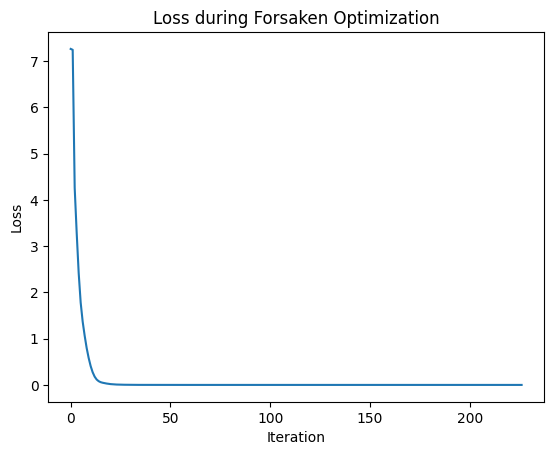

In [108]:
T = 100
lambda_ = 0
omega = 1.0
eta_mu = 0.2
xi = 3.0

model_forsaken_noise = forsaken(
    f_theta_0=model_noise,
    T=T,
    lambda_=lambda_,
    omega=omega,
    P=P,
    D_f=images_forget,  # batch d’images à oublier
    eta_mu=eta_mu,
    xi=xi,
    optimizer='LBFGS'
)


In [109]:
# Évaluer le modèle après Forsaken sur le forget set
accuracy_forget_noise = evaluate_model(model_forsaken_noise, forget_loader)
print(f"🔁 Accuracy sur D_f après Forsaken : {accuracy_forget_noise:.2f}%")

# Évaluer le modèle initial (model_noise) sur le forget set
accuracy_base_noise = evaluate_model(model_noise, forget_loader)
print(f"🎯 Accuracy sur D_f sans Forsaken : {accuracy_base_noise:.2f}%")

# Évaluer sur le test set standard
accuracy_forget_test = evaluate_model(model_forsaken_noise, test_loader)
print(f"🧪 Accuracy sur base de test après Forsaken : {accuracy_forget_test:.2f}%")

accuracy_base_test = evaluate_model(model_noise, test_loader)
print(f"✅ Accuracy sur base de test sans Forsaken : {accuracy_base_test:.2f}%")


🔁 Accuracy sur D_f après Forsaken : 48.35%
🎯 Accuracy sur D_f sans Forsaken : 96.93%
🧪 Accuracy sur base de test après Forsaken : 58.48%
✅ Accuracy sur base de test sans Forsaken : 92.42%
